In [1]:
%matplotlib inline
from secsy import cubedsphere as cs
from secsy import CSplot
from secsy import get_SECS_J_G_matrices, get_SECS_B_G_matrices
import lompe
import apexpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

RE = 6371.2e3
RI = RE + 110e3

theta0=0.25 # for j_G matrix singularity limit

Epoch = 2025. #REMEMBER TO CHANGE

# make cubed sphere projection and grid
location = (-40,71)
orientation = 0
L, W, Lres, Wres = 2500e3,3500e3,100.0e3,100.0e3

projection = cs.CSprojection(location, orientation)
grid = cs.CSgrid(projection, L, W, Lres, Wres, R = RI, wshift=1.0)

shp = grid.shape

# make lompe model, used to compute gradient matrices in magnetic east/west (conductances don't matter for us)
model = lompe.Emodel(grid, Hall_Pedersen_conductance = (0,0), epoch=Epoch, ew_regularization_limit=(70,89))

# Define meridian
meridian_lat_qd = np.arange(60, 86+0.2, 0.2)
meridian_lon_qd = np.ones(len(meridian_lat_qd))*50

apex_obj = apexpy.Apex(date=datetime(2025, 2, 12), refh=110)
meridian_lat_geo, meridian_lon_geo = apex_obj.convert(meridian_lat_qd, meridian_lon_qd, 'qd', 'geo')

In [3]:
ss = slice(0, -1, 3) # downsample for vector plots
la, lo = grid.lat_mesh[ss, ss], grid.lon_mesh[ss, ss]

# matrices that calculate currents (for plotting vectors):
Gej, Gnj = get_SECS_J_G_matrices(la, lo, grid.lat, grid.lon, singularity_limit = theta0 * np.pi / 180 * RI) 
# and magnetic field on ground (evaluated on the full "mesh" grid, not downsampled):
GeB, GnB, GuB = get_SECS_B_G_matrices(grid.lat_mesh, grid.lon_mesh, RE, grid.lat, grid.lon)

**EYE-BALLING**

In [2]:
stations = np.load('stations_supermag.npy', allow_pickle=True)
times_sup = np.load('concurrent_times_supermag.npy',allow_pickle=True)
times_dtu = np.load('concurrent_times_dtu.npy',allow_pickle=True)
times = np.intersect1d(times_sup, times_dtu)

In [ ]:
times[2]

np.datetime64('2023-02-23T14:02:00.000000')

In [3]:
from my_utils import load_and_combine_dtu
folders = ['GDH6', 'KUL2', 'KUV1', 'NAQ4m', 'NRD2', 'PIF4', 'SCO2', 'SKT1', 'STF2', 'SUM1', 'SVS1']

df232 = load_and_combine_dtu('20230224', folders, base_dir='dtu_downloads/yearly_BASELINE_rotated')
df233 = load_and_combine_dtu('20230330', folders, base_dir='dtu_downloads/yearly_BASELINE_rotated')
df2411 = load_and_combine_dtu('20241112', folders, base_dir='dtu_downloads/yearly_BASELINE_rotated')

In [4]:
df1 = df232[df232['time']==datetime(2023,2,24,6,15,0)]
df2 = df233[df233['time']==datetime(2023,3,30,12,0,0)]
df3 = df2411[df2411['time']==datetime(2024,11,17,20,0,0)]

for dfs in [df1,df2,df3]:
    print(dfs.empty)

False
False
False


In [5]:
stations = df1['iaga'].values
# Path to your CSV file
file_path = "dtu_stations.csv"

# Read CSV
df_loc = pd.read_csv(file_path)

# Make sure column names match your file exactly
# Adjust these if necessary after checking df.columns
iaga_column = "IAGA"
lat_column = "lat_gd"
lon_column = "lon_gd"

# Filter stations based on IAGA list (and sort by station name so it matches df_mag)
filtered_df = df_loc[df_loc[iaga_column].isin(stations)].sort_values('IAGA')

# Extract latitude and longitude vectors
lat_mag = filtered_df[lat_column].to_numpy()
lon_mag = filtered_df[lon_column].to_numpy()

xi_mag, eta_mag = projection.geo2cube(lon_mag, lat_mag)

ss = slice(0, -1, 3) # downsample for vector plots
la, lo = grid.lat_mesh[ss, ss], grid.lon_mesh[ss, ss]

In [ ]:
# change regularization parameters
T0, T1 = 5e-24, 1e-21
#T0, T1 = 7e-24, 1e-21
# change to include telluuric currents
telluric = True
depth = 350e3 # depth where Br = 0 [m]
#depth = 1000e3 

# matrices that calculate currents (for plotting vectors):
Gej, Gnj = get_SECS_J_G_matrices(la, lo, grid.lat, grid.lon, singularity_limit = theta0 * np.pi / 180 * RI) 
# and magnetic field on ground (evaluated on the full "mesh" grid, not downsampled):
if telluric:
    GeB, GnB, GuB = get_SECS_B_G_matrices(grid.lat_mesh, grid.lon_mesh, RE, grid.lat, grid.lon, induction_nullification_radius = RE - depth)
    GeB_mag, GnB_mag, GuB_mag = get_SECS_B_G_matrices(lat_mag, lon_mag, RE, grid.lat, grid.lon, induction_nullification_radius = RE - depth)
else:
    GeB, GnB, GuB = get_SECS_B_G_matrices(grid.lat_mesh, grid.lon_mesh, RE, grid.lat, grid.lon)
    GeB_mag, GnB_mag, GuB_mag = get_SECS_B_G_matrices(lat_mag, lon_mag, RE, grid.lat, grid.lon)


In [17]:
# --- Compute global limits before the loop ---
Bu_all = []
Bu_mag_all = []
Be_all, Bn_all = [], []
Be_mag_all, Bn_mag_all = [], []
I_2_all = []
times_all = []

for i, dfs in enumerate([df1, df2, df3]):
    Be_mag, Bn_mag, Bu_mag = dfs['Y'].values, dfs['X'].values, -dfs['Z'].values

    G = np.vstack((GeB_mag, GnB_mag, GuB_mag))
    d = np.hstack((Be_mag, Bn_mag, Bu_mag)) * 10**(-9)
    Le, Ln, LTLe, LTLn = model.compute_L_matrices(grid)
    GTG, GTd = G.T.dot(G), G.T.dot(d)
    LTL = LTLe
    R = T0 * np.eye(grid.size) + T1 * LTL
    I_2 = np.linalg.lstsq(GTG + R, GTd, rcond=0)[0]

    Bu = GuB.dot(I_2).reshape(grid.lat_mesh.shape)
    Be = GeB.dot(I_2).reshape(grid.lat_mesh.shape)
    Bn = GnB.dot(I_2).reshape(grid.lat_mesh.shape)

    Bu_all.append(Bu)
    Bu_mag_all.append(Bu_mag)
    Be_all.append(Be[ss, ss].flatten())
    Bn_all.append(Bn[ss, ss].flatten())
    Be_mag_all.append(Be_mag.flatten())
    Bn_mag_all.append(Bn_mag.flatten())
    I_2_all.append(I_2)
    times_all.append(str(dfs['time'].values[0]))

# Shared color limit: symmetric, covering both model and data
Bu_abs_max = max(
    np.abs(np.concatenate([b.flatten() for b in Bu_all])).max(),
    np.abs(np.concatenate(Bu_mag_all)).max() * 1e-9  # convert nT to T to match model units
)

# Shared quiver scale: based on max arrow magnitude across model + data
mag_model = [np.sqrt(be**2 + bn**2).max() for be, bn in zip(Be_all, Bn_all)]
mag_data  = [np.sqrt(be**2 + bn**2).max() * 1e-9 for be, bn in zip(Be_mag_all, Bn_mag_all)]
quiver_scale = max(max(mag_model), max(mag_data)) * 20  # tune multiplier as needed

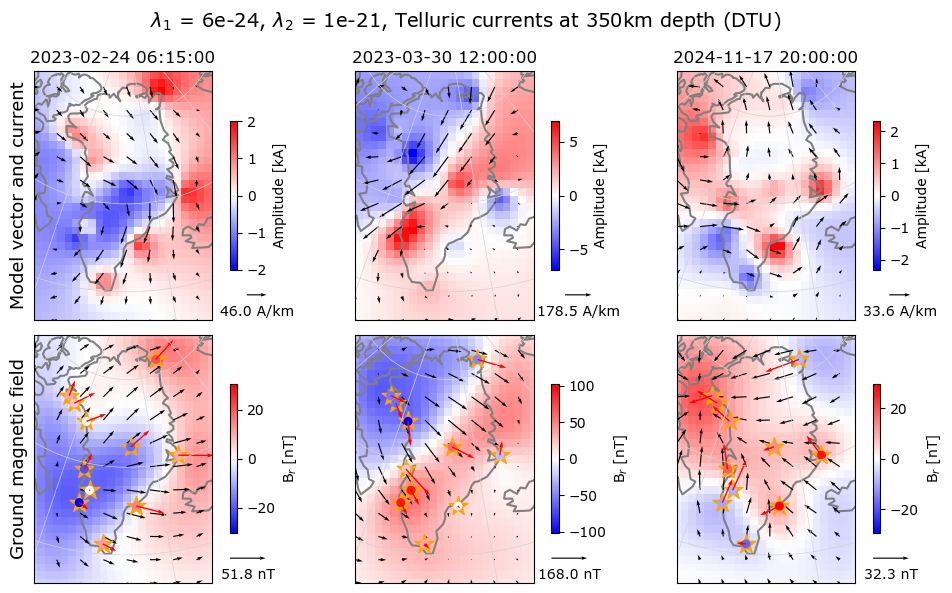

In [18]:
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(10, 6))
csaxes = [CSplot(ax, grid, gridtype='geo') for ax in axes.flatten()]

for i in range(3):
    csaxes[i].ax.set_title((times_all[i])[:19].replace('T', ' '))

    pcm = csaxes[i].pcolormesh(
        grid.lon_mesh, grid.lat_mesh, I_2_all[i].reshape(shp)/1000,
        cmap=plt.cm.bwr,
        vmin=-np.abs(I_2_all[i]).max()/1000,
        vmax= np.abs(I_2_all[i]).max()/1000,
        zorder=0
    )
    csaxes[i].add_coastlines(color='grey', resolution='110m', zorder=1)

    je = Gej.dot(I_2_all[i]).reshape(la.shape)*1000
    jn = Gnj.dot(I_2_all[i]).reshape(la.shape)*1000
    Q = csaxes[i].quiver(je, jn, lo, la)

    # Colorbar shifted upward
    cb = plt.colorbar(pcm, ax=csaxes[i].ax, label='Amplitude [kA]', shrink=0.6, pad=0.06)
    cb.ax.yaxis.set_label_position('right')
    # Shift colorbar up
    pos = cb.ax.get_position()
    cb.ax.set_position([pos.x0, pos.y0 + 0.05, pos.width, pos.height])

    # Quiverkey below the colorbar
    ref_mag = np.sqrt(je**2 + jn**2).max()
    csaxes[i].ax.quiverkey(Q, X=1.25, Y=0.1, U=ref_mag,
                            label=f'{ref_mag:.1f} A/km', labelpos='S',
                            coordinates='axes')

    # --- Bottom row ---
    Bu_abs_max_i = max(
        np.abs(Bu_all[i]).max() * 1e9,
        np.abs(Bu_mag_all[i]).max()
    )
    mag_model_i  = np.sqrt((Be_all[i]*1e9)**2 + (Bn_all[i]*1e9)**2).max()
    mag_data_i   = np.sqrt(Be_mag_all[i]**2 + Bn_mag_all[i]**2).max()
    quiver_scale_i = max(mag_model_i, mag_data_i) * 5

    pcm_bot = csaxes[i+3].pcolormesh(
        grid.lon_mesh, grid.lat_mesh, Bu_all[i]*1e9,
        cmap=plt.cm.bwr, vmin=-Bu_abs_max_i, vmax=Bu_abs_max_i, zorder=0
    )
    csaxes[i+3].add_coastlines(color='grey', resolution='110m', zorder=1)

    Q_bot = csaxes[i+3].quiver(
        Be_all[i].flatten()*1e9, Bn_all[i].flatten()*1e9,
        lo, la, scale=quiver_scale_i
    )
    csaxes[i+3].ax.scatter(xi_mag, eta_mag, c='orange', s=200, marker='*')
    csaxes[i+3].ax.scatter(
        xi_mag, eta_mag, c=Bu_mag_all[i],
        s=30, cmap=plt.cm.bwr, vmin=-Bu_abs_max_i, vmax=Bu_abs_max_i
    )
    csaxes[i+3].quiver(
        Be_mag_all[i].flatten(), Bn_mag_all[i].flatten(),
        lon_mag, lat_mag,
        color='red', scale=quiver_scale_i
    )

    # Colorbar shifted upward
    cb_bot = plt.colorbar(pcm_bot, ax=csaxes[i+3].ax, label='B$_r$ [nT]', shrink=0.6, pad=0.06)
    cb_bot.ax.yaxis.set_label_position('right')
    # Shift colorbar up
    pos_bot = cb_bot.ax.get_position()
    cb_bot.ax.set_position([pos_bot.x0, pos_bot.y0 + 0.05, pos_bot.width, pos_bot.height])

    # Quiverkey below the colorbar
    ref_mag_bot = max(mag_model_i, mag_data_i)
    csaxes[i+3].ax.quiverkey(Q_bot, X=1.20, Y=0.1, U=ref_mag_bot,
                               label=f'{ref_mag_bot:.1f} nT', labelpos='S',
                               coordinates='axes')

csaxes[0].ax.set_ylabel('Model vector and current', fontsize=13)
csaxes[3].ax.set_ylabel('Ground magnetic field', fontsize=13)

if telluric:
    fig.suptitle(f'$\lambda_1$ = {T0}, $\lambda_2$ = {T1}, Telluric currents at {int(depth/1000)}km depth (DTU)', fontsize=14)
else:
    fig.suptitle(f'$\lambda_1$ = {T0}, $\lambda_2$ = {T1}, without telluric (DTU)', fontsize=14)

plt.tight_layout()
#plt.savefig('figures/regularization_smooth.svg', format='svg', bbox_inches='tight')
plt.show()

**NOTE TO SELF (DISCOVERIES):**

Mere smoothing gør både horizontal og vertical field svagere. Dette kan dog kombineres med en ændring af telluric depth for at forbedre data misfit. Mindre depth gør horizontal stærkere men vertical svagere og vice versa.

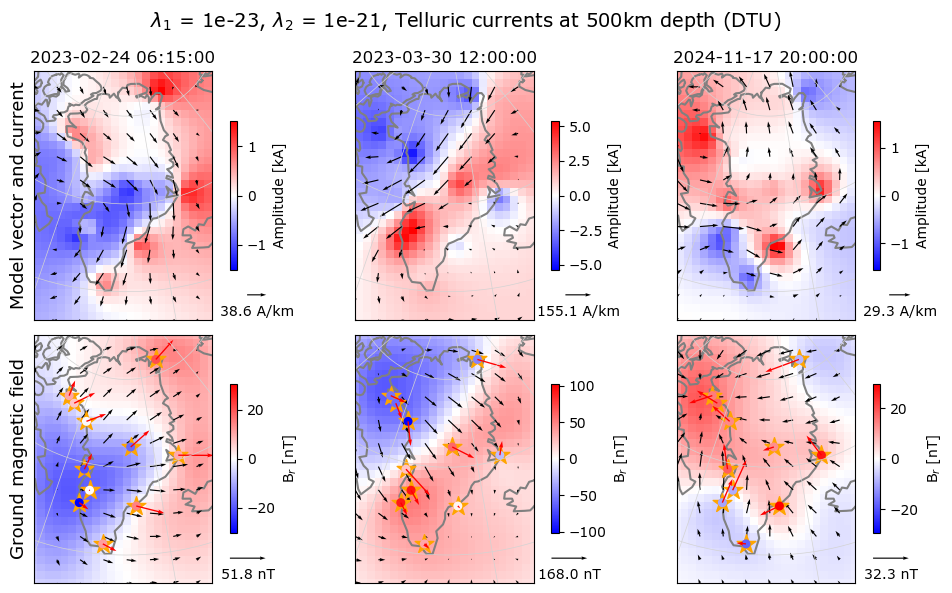

In [9]:
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(10, 6))
csaxes = [CSplot(ax, grid, gridtype='geo') for ax in axes.flatten()]

for i in range(3):
    csaxes[i].ax.set_title((times_all[i])[:19].replace('T', ' '))

    pcm = csaxes[i].pcolormesh(
        grid.lon_mesh, grid.lat_mesh, I_2_all[i].reshape(shp)/1000,
        cmap=plt.cm.bwr,
        vmin=-np.abs(I_2_all[i]).max()/1000,
        vmax= np.abs(I_2_all[i]).max()/1000,
        zorder=0
    )
    csaxes[i].add_coastlines(color='grey', resolution='110m', zorder=1)

    je = Gej.dot(I_2_all[i]).reshape(la.shape)*1000
    jn = Gnj.dot(I_2_all[i]).reshape(la.shape)*1000
    Q = csaxes[i].quiver(je, jn, lo, la)

    # Colorbar shifted upward
    cb = plt.colorbar(pcm, ax=csaxes[i].ax, label='Amplitude [kA]', shrink=0.6, pad=0.06)
    cb.ax.yaxis.set_label_position('right')
    # Shift colorbar up
    pos = cb.ax.get_position()
    cb.ax.set_position([pos.x0, pos.y0 + 0.05, pos.width, pos.height])

    # Quiverkey below the colorbar
    ref_mag = np.sqrt(je**2 + jn**2).max()
    csaxes[i].ax.quiverkey(Q, X=1.25, Y=0.1, U=ref_mag,
                            label=f'{ref_mag:.1f} A/km', labelpos='S',
                            coordinates='axes')

    # --- Bottom row ---
    Bu_abs_max_i = max(
        np.abs(Bu_all[i]).max() * 1e9,
        np.abs(Bu_mag_all[i]).max()
    )
    mag_model_i  = np.sqrt((Be_all[i]*1e9)**2 + (Bn_all[i]*1e9)**2).max()
    mag_data_i   = np.sqrt(Be_mag_all[i]**2 + Bn_mag_all[i]**2).max()
    quiver_scale_i = max(mag_model_i, mag_data_i) * 5

    pcm_bot = csaxes[i+3].pcolormesh(
        grid.lon_mesh, grid.lat_mesh, Bu_all[i]*1e9,
        cmap=plt.cm.bwr, vmin=-Bu_abs_max_i, vmax=Bu_abs_max_i, zorder=0
    )
    csaxes[i+3].add_coastlines(color='grey', resolution='110m', zorder=1)

    Q_bot = csaxes[i+3].quiver(
        Be_all[i].flatten()*1e9, Bn_all[i].flatten()*1e9,
        lo, la, scale=quiver_scale_i
    )
    csaxes[i+3].ax.scatter(xi_mag, eta_mag, c='orange', s=200, marker='*')
    csaxes[i+3].ax.scatter(
        xi_mag, eta_mag, c=Bu_mag_all[i],
        s=30, cmap=plt.cm.bwr, vmin=-Bu_abs_max_i, vmax=Bu_abs_max_i
    )
    csaxes[i+3].quiver(
        Be_mag_all[i].flatten(), Bn_mag_all[i].flatten(),
        lon_mag, lat_mag,
        color='red', scale=quiver_scale_i
    )

    # Colorbar shifted upward
    cb_bot = plt.colorbar(pcm_bot, ax=csaxes[i+3].ax, label='B$_r$ [nT]', shrink=0.6, pad=0.06)
    cb_bot.ax.yaxis.set_label_position('right')
    # Shift colorbar up
    pos_bot = cb_bot.ax.get_position()
    cb_bot.ax.set_position([pos_bot.x0, pos_bot.y0 + 0.05, pos_bot.width, pos_bot.height])

    # Quiverkey below the colorbar
    ref_mag_bot = max(mag_model_i, mag_data_i)
    csaxes[i+3].ax.quiverkey(Q_bot, X=1.20, Y=0.1, U=ref_mag_bot,
                               label=f'{ref_mag_bot:.1f} nT', labelpos='S',
                               coordinates='axes')

csaxes[0].ax.set_ylabel('Model vector and current', fontsize=13)
csaxes[3].ax.set_ylabel('Ground magnetic field', fontsize=13)

if telluric:
    fig.suptitle(f'$\lambda_1$ = {T0}, $\lambda_2$ = {T1}, Telluric currents at {int(depth/1000)}km depth (DTU)', fontsize=14)
else:
    fig.suptitle(f'$\lambda_1$ = {T0}, $\lambda_2$ = {T1}, without telluric (DTU)', fontsize=14)

plt.tight_layout()
#plt.savefig('figures/regularization_smooth.svg', format='svg', bbox_inches='tight')
plt.show()